**📊 About the Dataset**:

This dataset contains information about vehicle insurance policies, insured individuals, and claim incidents. It is used to build a model that predicts whether a claim is fraudulent or not.

🔍 Column Description:

**policy_id:** Unique identifier assigned to each insurance policy.

**policy_state:** The state where the insurance policy was issued.

**policy_deductible**: The deductible amount that the policyholder must pay before the insurance covers the claim.

**policy_annual_premium:** The yearly amount paid by the policyholder for the insurance coverage.

**insured_age:** Age of the insured person at the time of the policy.

**insured_sex:** Gender of the insured individual.

**insured_education_level:** The highest education level attained by the insured person.

**insured_occupation:** The occupation or job of the insured individual.

**insured_hobbies:** Hobbies of the insured person, which may correlate with risk behavior.

**incident_date:** The date when the incident (accident) occurred.

**incident_type:** The type of incident (e.g., collision, theft, etc.).

**collision_type:** Describes how the collision happened (e.g., rear-end, side-impact).

**incident_severity:** Indicates how severe the incident was.

**authorities_contacted:** Specifies which authorities were contacted (e.g., police).

**incident_state:** The state where the incident occurred.

**incident_city:** The city where the incident took place.

**incident_hour_of_the_day:** The hour of the day when the incident happened.

**number_of_vehicles_involved:** Total number of vehicles involved in the incident.

**bodily_injuries:** Number of people who were injured in the incident.

**witnesses:** Number of witnesses present at the scene.

**police_report_available:** Indicates whether a police report is available or not.

**claim_amount:** The amount claimed by the policyholder for the incident.

**total_claim_amount:** The total amount paid by the insurance company for the claim.

**fraud_reported:** Target variable indicating whether the claim is fraudulent (Yes/No).


Loading data and importing Libraries

In [169]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from missingno import missingno as msno
from datetime import datetime
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

In [171]:
df = pd.read_csv('/content/drive/MyDrive/DataSets/car_insurance_fraud_dataset.csv')
df

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,...,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,...,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,...,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,...,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,...,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,POL129995,NY,200,973.40,47,FEMALE,Masters,Lawyer,paintball,2025-04-04,...,IL,West Natashaside,5,3,1,1,No,10502.67,16070.08,N
29996,POL129996,CA,300,869.67,38,MALE,Masters,Sales,hiking,2025-05-22,...,FL,Yanghaven,8,3,3,2,No,18892.03,17314.60,N
29997,POL129997,FL,600,1169.47,57,OTHER,College,Doctor,reading,2025-09-09,...,TX,East Jeffreyside,7,4,3,1,Yes,2777.06,2954.09,N
29998,POL129998,MI,800,989.41,67,MALE,PhD,Doctor,camping,2024-10-14,...,TX,Johnsonmouth,5,2,2,1,No,4845.58,5945.18,N


EDA

In [172]:
df.shape

(30000, 24)

In [173]:
df.head(10)

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,...,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,...,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,...,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,...,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,...,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N
5,POL100005,PA,700,1015.60,32,MALE,College,Manager,camping,2025-03-11,...,FL,Bethfort,20,2,4,5,No,12483.84,11780.94,N
6,POL100006,PA,300,1254.39,30,OTHER,High School,Doctor,reading,2024-12-26,...,PA,Masonport,16,4,0,3,Yes,16687.40,19045.75,N
7,POL100007,MI,700,1288.08,29,FEMALE,PhD,Lawyer,reading,2025-10-19,...,MI,North Randytown,5,1,3,5,No,7111.40,8272.63,N
8,POL100008,NC,500,942.22,61,FEMALE,College,Clerk,yachting,2023-11-19,...,NC,Jerryberg,22,1,4,5,Yes,1603.74,2549.55,N
9,POL100009,GA,700,1277.15,19,OTHER,High School,Doctor,chess,2024-05-07,...,FL,Newtonshire,17,3,3,0,No,18778.37,15959.84,N


In [174]:
df.tail(10)

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
29990,POL129990,NY,400,1036.66,63,FEMALE,High School,Doctor,hiking,2025-01-25,...,MI,South Brittany,11,3,4,0,No,8002.38,7141.24,N
29991,POL129991,MI,800,1462.57,63,MALE,College,Doctor,camping,2025-07-02,...,NC,Huangtown,18,4,2,2,No,4860.90,4874.55,N
29992,POL129992,NC,700,739.74,31,OTHER,College,Manager,yachting,2025-05-19,...,IL,Laneberg,5,1,2,4,Yes,13620.43,14153.38,N
29993,POL129993,NC,600,1352.44,67,FEMALE,PhD,Technician,yachting,2024-09-29,...,CA,Vazquezport,1,4,0,1,Yes,11384.18,14100.52,N
29994,POL129994,OH,800,1094.48,71,OTHER,PhD,Technician,camping,2024-05-11,...,PA,Gonzalezstad,19,2,3,2,Yes,18195.99,23913.98,N
29995,POL129995,NY,200,973.40,47,FEMALE,Masters,Lawyer,paintball,2025-04-04,...,IL,West Natashaside,5,3,1,1,No,10502.67,16070.08,N
29996,POL129996,CA,300,869.67,38,MALE,Masters,Sales,hiking,2025-05-22,...,FL,Yanghaven,8,3,3,2,No,18892.03,17314.60,N
29997,POL129997,FL,600,1169.47,57,OTHER,College,Doctor,reading,2025-09-09,...,TX,East Jeffreyside,7,4,3,1,Yes,2777.06,2954.09,N
29998,POL129998,MI,800,989.41,67,MALE,PhD,Doctor,camping,2024-10-14,...,TX,Johnsonmouth,5,2,2,1,No,4845.58,5945.18,N
29999,POL129999,FL,1000,615.26,34,MALE,PhD,Teacher,camping,2024-04-29,...,MI,Brianport,17,3,4,4,No,9569.02,10828.73,N


In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_id                    30000 non-null  object 
 1   policy_state                 30000 non-null  object 
 2   policy_deductible            30000 non-null  int64  
 3   policy_annual_premium        30000 non-null  float64
 4   insured_age                  30000 non-null  int64  
 5   insured_sex                  30000 non-null  object 
 6   insured_education_level      30000 non-null  object 
 7   insured_occupation           30000 non-null  object 
 8   insured_hobbies              30000 non-null  object 
 9   incident_date                30000 non-null  object 
 10  incident_type                30000 non-null  object 
 11  collision_type               30000 non-null  object 
 12  incident_severity            30000 non-null  object 
 13  authorities_cont

In [176]:
df.describe()

,policy_deductible,policy_annual_premium,insured_age,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,claim_amount,total_claim_amount
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,562.783333,1051.255214,46.500133,11.505000,2.508933,1.997600,2.504667,10823.078981,12757.736600
std,250.413012,260.357163,16.707778,6.896155,1.116555,1.411829,1.707691,6629.690781,7028.920069
min,200.000000,600.020000,18.000000,0.000000,1.000000,0.000000,0.000000,266.740000,502.180000
25%,300.000000,826.320000,32.000000,6.000000,2.000000,1.000000,1.000000,5350.947500,6685.507500
50%,600.000000,1051.155000,46.000000,12.000000,3.000000,2.000000,2.000000,10204.170000,12740.430000
75%,800.000000,1277.902500,61.000000,17.000000,4.000000,3.000000,4.000000,15381.867500,18809.910000
max,1000.000000,1499.980000,75.000000,23.000000,4.000000,4.000000,5.000000,29719.870000,24999.720000


In [177]:
df.isnull().sum()

,0
policy_id,0
policy_state,0
policy_deductible,0
policy_annual_premium,0
insured_age,0
insured_sex,0
insured_education_level,0
insured_occupation,0
insured_hobbies,0
incident_date,0


<Axes: >

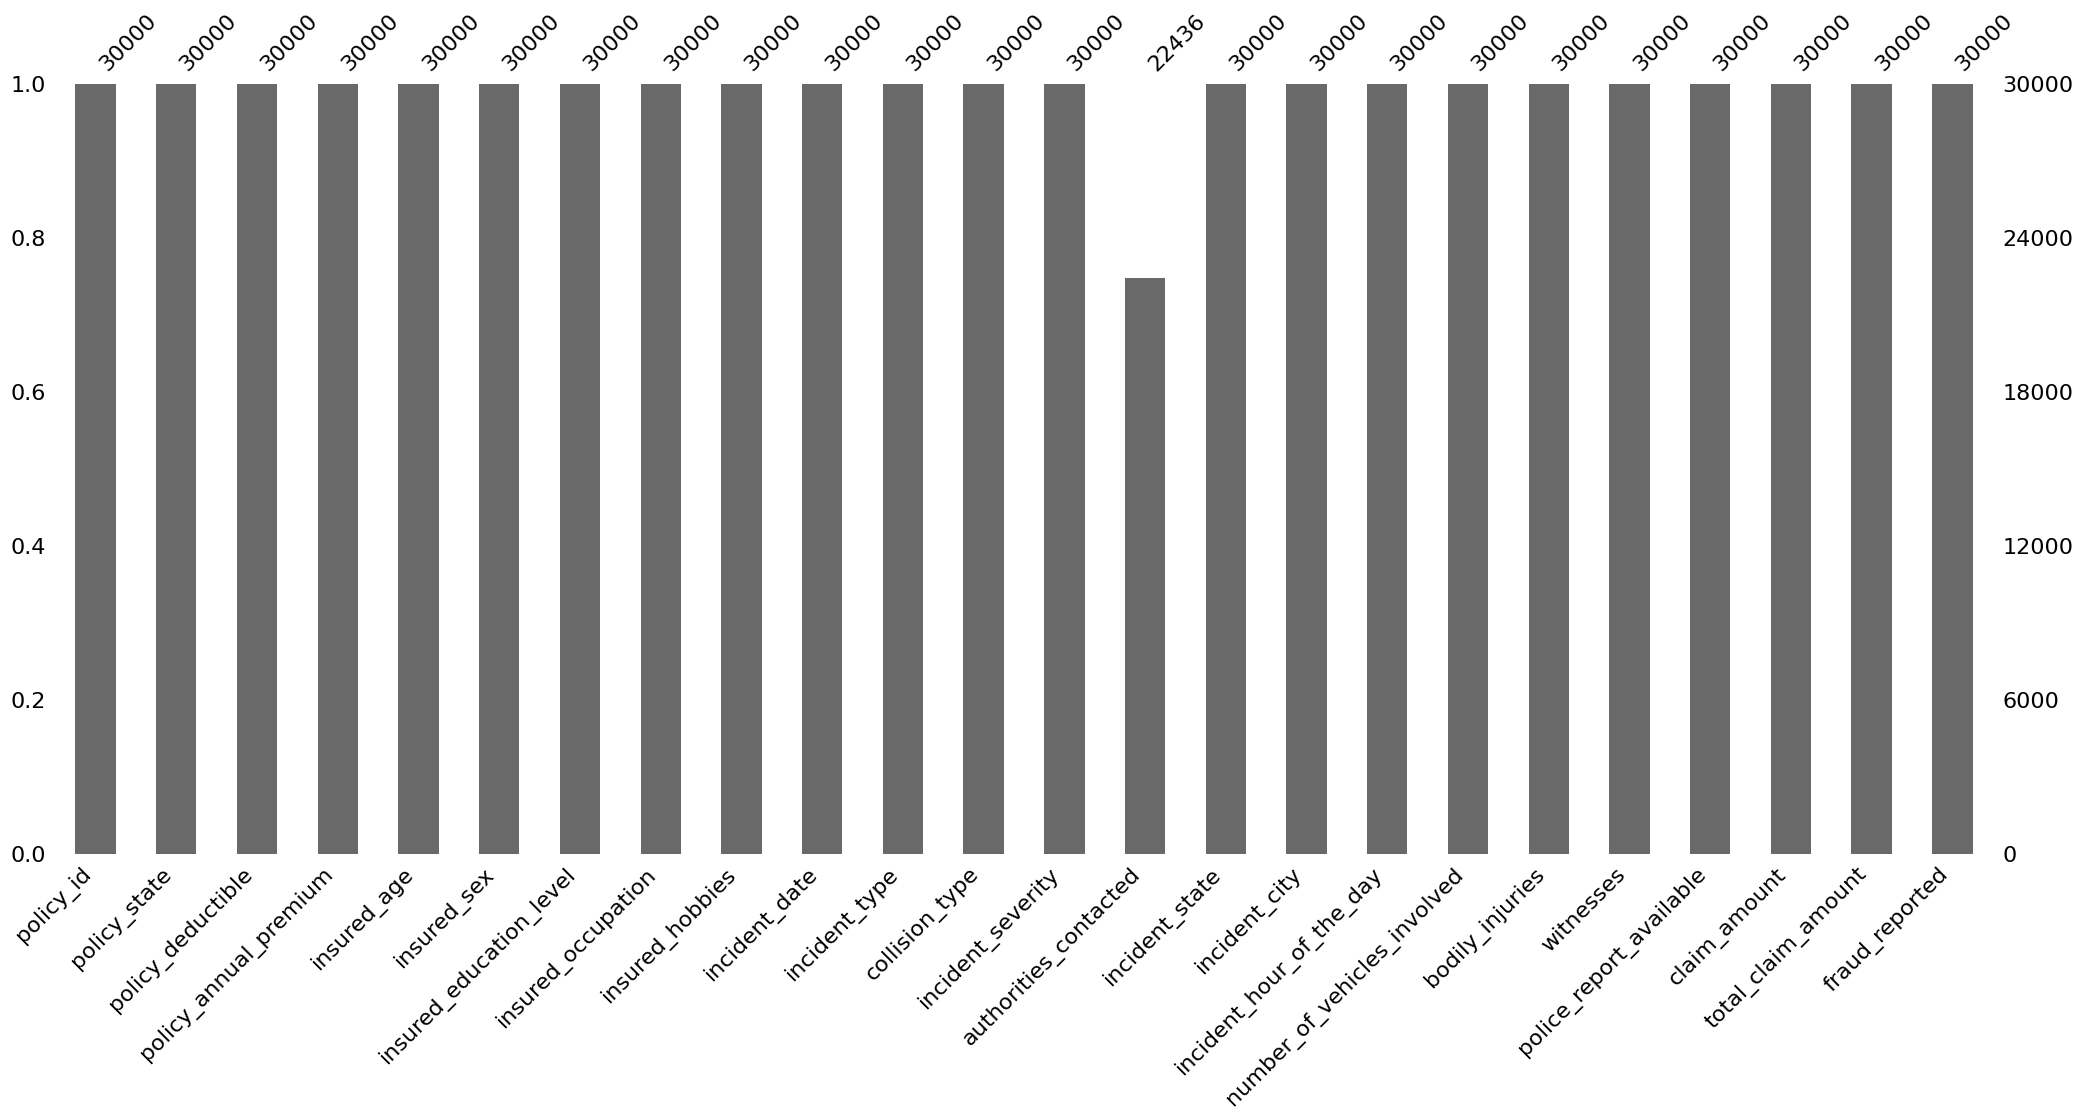

In [178]:
msno.bar(df)

In [179]:
df['authorities_contacted'].value_counts()

,count
authorities_contacted,
Fire,7569
Police,7498
Ambulance,7369


In [180]:
df['authorities_contacted'].head(20)

,authorities_contacted
0,NaN
1,NaN
2,Police
3,Police
4,Fire
5,Ambulance
6,Ambulance
7,Police
8,Ambulance
9,Ambulance


In [181]:
df['policy_state'].value_counts()

,count
policy_state,
GA,3133
NY,3034
OH,3026
MI,3004
PA,2997
NC,2990
FL,2981
IL,2973
CA,2951


In [182]:
df['insured_sex'].value_counts()

,count
insured_sex,
OTHER,10088
MALE,10037
FEMALE,9875


In [183]:
df.columns

Index(['policy_id', 'policy_state', 'policy_deductible',
       'policy_annual_premium', 'insured_age', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'police_report_available',
       'claim_amount', 'total_claim_amount', 'fraud_reported'],
      dtype='object')

In [184]:
df.drop('policy_id', axis=1, inplace=True)

In [185]:
df.duplicated().sum()

np.int64(0)

In [186]:
df['incident_date'] = pd.to_datetime(df['incident_date'])
df['year'] = df['incident_date'].dt.year
df['month'] = df['incident_date'].dt.month
df['day'] = df['incident_date'].dt.day
df['day_of_week'] = df['incident_date'].dt.dayofweek
df

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,incident_type,...,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,year,month,day,day_of_week
0,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,Parked Car,...,4,0,Yes,8161.36,11677.60,Y,2024,6,13,3
1,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,Vehicle Theft,...,4,5,No,18561.79,18027.81,N,2025,3,23,6
2,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,Parked Car,...,4,1,No,10734.61,10375.59,N,2025,1,26,6
3,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,Parked Car,...,3,5,No,13188.92,14204.34,N,2024,6,3,0
4,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,Single Vehicle Collision,...,2,4,No,21864.69,24038.84,N,2024,5,21,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,NY,200,973.40,47,FEMALE,Masters,Lawyer,paintball,2025-04-04,Vehicle Theft,...,1,1,No,10502.67,16070.08,N,2025,4,4,4
29996,CA,300,869.67,38,MALE,Masters,Sales,hiking,2025-05-22,Parked Car,...,3,2,No,18892.03,17314.60,N,2025,5,22,3
29997,FL,600,1169.47,57,OTHER,College,Doctor,reading,2025-09-09,Multi-vehicle Collision,...,3,1,Yes,2777.06,2954.09,N,2025,9,9,1
29998,MI,800,989.41,67,MALE,PhD,Doctor,camping,2024-10-14,Parked Car,...,2,1,No,4845.58,5945.18,N,2024,10,14,0


In [187]:
df['year'].value_counts()

,count
year,
2024,14986
2025,12906
2023,2108


In [188]:
df['month'].value_counts()

,count
month,
1,2703
8,2596
10,2567
3,2560
7,2537
5,2534
11,2475
12,2442
4,2420


In [189]:
df['day'].value_counts()

,count
day,
15,1056
20,1037
22,1024
18,1017
9,1016
23,1007
19,1006
2,1002
17,1002


In [190]:
df['day_of_week'].value_counts()

,count
day_of_week,
2,4379
6,4322
1,4302
0,4299
4,4285
3,4229
5,4184


In [191]:
df.drop('incident_date', axis=1, inplace=True)

In [192]:
df.drop('incident_city', axis=1, inplace=True) #it it too much 17931

In [193]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['policy_deductible', 'policy_annual_premium', 'insured_age',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'claim_amount', 'total_claim_amount',
       'year', 'month', 'day', 'day_of_week'],
      dtype='object')

In [194]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['policy_state', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'police_report_available', 'fraud_reported'],
      dtype='object')

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   policy_state                 30000 non-null  object 
 1   policy_deductible            30000 non-null  int64  
 2   policy_annual_premium        30000 non-null  float64
 3   insured_age                  30000 non-null  int64  
 4   insured_sex                  30000 non-null  object 
 5   insured_education_level      30000 non-null  object 
 6   insured_occupation           30000 non-null  object 
 7   insured_hobbies              30000 non-null  object 
 8   incident_type                30000 non-null  object 
 9   collision_type               30000 non-null  object 
 10  incident_severity            30000 non-null  object 
 11  authorities_contacted        22436 non-null  object 
 12  incident_state               30000 non-null  object 
 13  incident_hour_of

In [196]:
for col in cat_cols:
  df[col] = df[col].str.strip().str.lower()

In [197]:
df['policy_state'].value_counts()

,count
policy_state,
ga,3133
ny,3034
oh,3026
mi,3004
pa,2997
nc,2990
fl,2981
il,2973
ca,2951


In [198]:
df['incident_type'].value_counts()

,count
incident_type,
vehicle theft,7581
multi-vehicle collision,7547
single vehicle collision,7519
parked car,7353


In [199]:
df['insured_education_level'].value_counts()

,count
insured_education_level,
high school,7554
phd,7514
masters,7477
college,7455


In [200]:
df['insured_occupation'].value_counts()

,count
insured_occupation,
teacher,3799
doctor,3778
manager,3777
clerk,3773
technician,3758
lawyer,3725
sales,3702
engineer,3688


In [201]:
df['insured_hobbies'].value_counts()

,count
insured_hobbies,
paintball,4345
hiking,4328
yachting,4296
camping,4284
reading,4265
movies,4258
chess,4224


In [202]:
df

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,...,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported,year,month,day,day_of_week
0,ga,400,1430.78,74,other,high school,manager,reading,parked car,front,...,4,0,yes,8161.36,11677.60,y,2024,6,13,3
1,pa,300,854.49,74,male,college,lawyer,chess,vehicle theft,rear,...,4,5,no,18561.79,18027.81,n,2025,3,23,6
2,mi,400,1247.28,28,other,phd,doctor,reading,parked car,unknown,...,4,1,no,10734.61,10375.59,n,2025,1,26,6
3,ca,600,622.42,37,male,phd,teacher,yachting,parked car,rear,...,3,5,no,13188.92,14204.34,n,2024,6,3,0
4,mi,700,1458.17,31,other,phd,sales,reading,single vehicle collision,side,...,2,4,no,21864.69,24038.84,n,2024,5,21,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,ny,200,973.40,47,female,masters,lawyer,paintball,vehicle theft,unknown,...,1,1,no,10502.67,16070.08,n,2025,4,4,4
29996,ca,300,869.67,38,male,masters,sales,hiking,parked car,unknown,...,3,2,no,18892.03,17314.60,n,2025,5,22,3
29997,fl,600,1169.47,57,other,college,doctor,reading,multi-vehicle collision,unknown,...,3,1,yes,2777.06,2954.09,n,2025,9,9,1
29998,mi,800,989.41,67,male,phd,doctor,camping,parked car,front,...,2,1,no,4845.58,5945.18,n,2024,10,14,0


In [203]:
print("num cols: ", num_cols)
print("cat cols: ", cat_cols)

num cols:  Index(['policy_deductible', 'policy_annual_premium', 'insured_age',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'claim_amount', 'total_claim_amount',
       'year', 'month', 'day', 'day_of_week'],
      dtype='object')
cat cols:  Index(['policy_state', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'police_report_available', 'fraud_reported'],
      dtype='object')


Outliers

In [204]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[num_cols])<(Q1-1.5*IQR)) | ((df[num_cols])>(Q3+1.5*IQR))
outliers

,policy_deductible,policy_annual_premium,insured_age,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,claim_amount,total_claim_amount,year,month,day,day_of_week
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,False,False,False,False,False,False,False,False,False,False,False,False,False
29996,False,False,False,False,False,False,False,False,False,False,False,False,False
29997,False,False,False,False,False,False,False,False,False,False,False,False,False
29998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [205]:
df[num_cols].describe()

,policy_deductible,policy_annual_premium,insured_age,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,claim_amount,total_claim_amount,year,month,day,day_of_week
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,562.783333,1051.255214,46.500133,11.505000,2.508933,1.997600,2.504667,10823.078981,12757.736600,2024.359933,6.475733,15.776733,2.991300
std,250.413012,260.357163,16.707778,6.896155,1.116555,1.411829,1.707691,6629.690781,7028.920069,0.609038,3.460628,8.789713,2.001655
min,200.000000,600.020000,18.000000,0.000000,1.000000,0.000000,0.000000,266.740000,502.180000,2023.000000,1.000000,1.000000,0.000000
25%,300.000000,826.320000,32.000000,6.000000,2.000000,1.000000,1.000000,5350.947500,6685.507500,2024.000000,3.000000,8.000000,1.000000
50%,600.000000,1051.155000,46.000000,12.000000,3.000000,2.000000,2.000000,10204.170000,12740.430000,2024.000000,7.000000,16.000000,3.000000
75%,800.000000,1277.902500,61.000000,17.000000,4.000000,3.000000,4.000000,15381.867500,18809.910000,2025.000000,9.000000,23.000000,5.000000
max,1000.000000,1499.980000,75.000000,23.000000,4.000000,4.000000,5.000000,29719.870000,24999.720000,2025.000000,12.000000,31.000000,6.000000


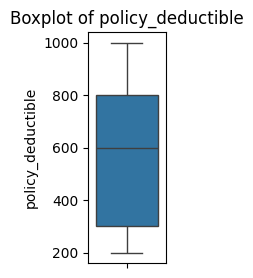

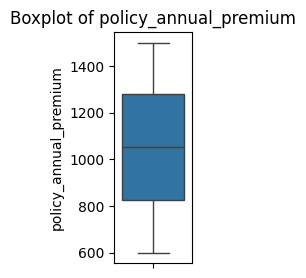

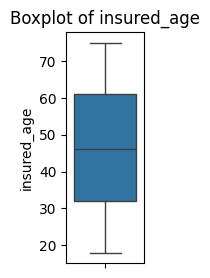

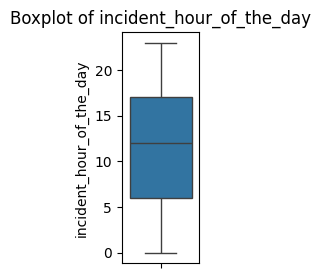

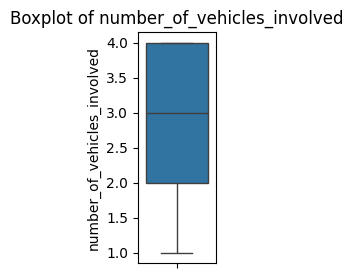

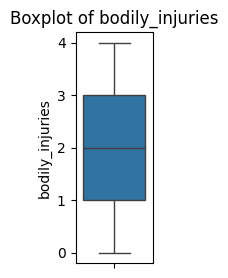

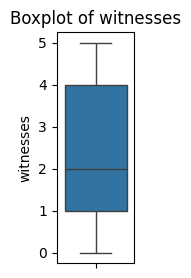

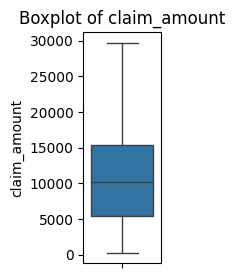

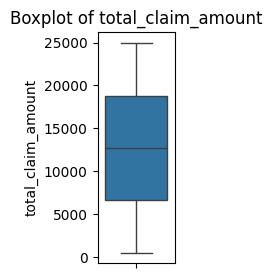

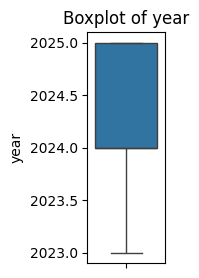

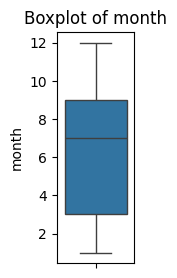

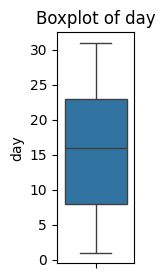

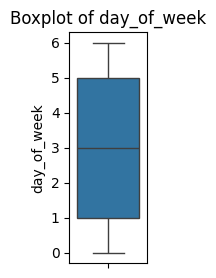

In [206]:
for col in num_cols:
  plt.figure(figsize=(1,3))
  sns.boxplot(df[col])
  plt.title(f"Boxplot of {col}")
  plt.show()

In [207]:
# No outliers

Balance data or not

In [208]:
df['fraud_reported'].value_counts()

,count
fraud_reported,
n,26560
y,3440


In [209]:
# not balanced

Missing values:

missinng values in 'authorities_contacted' were treated as a separate category ("None"), as the apsence of reported authorities is an important indecator for fraud detection.

In [210]:
df['authorities_contacted'] = df['authorities_contacted'].fillna('None')

<Axes: >

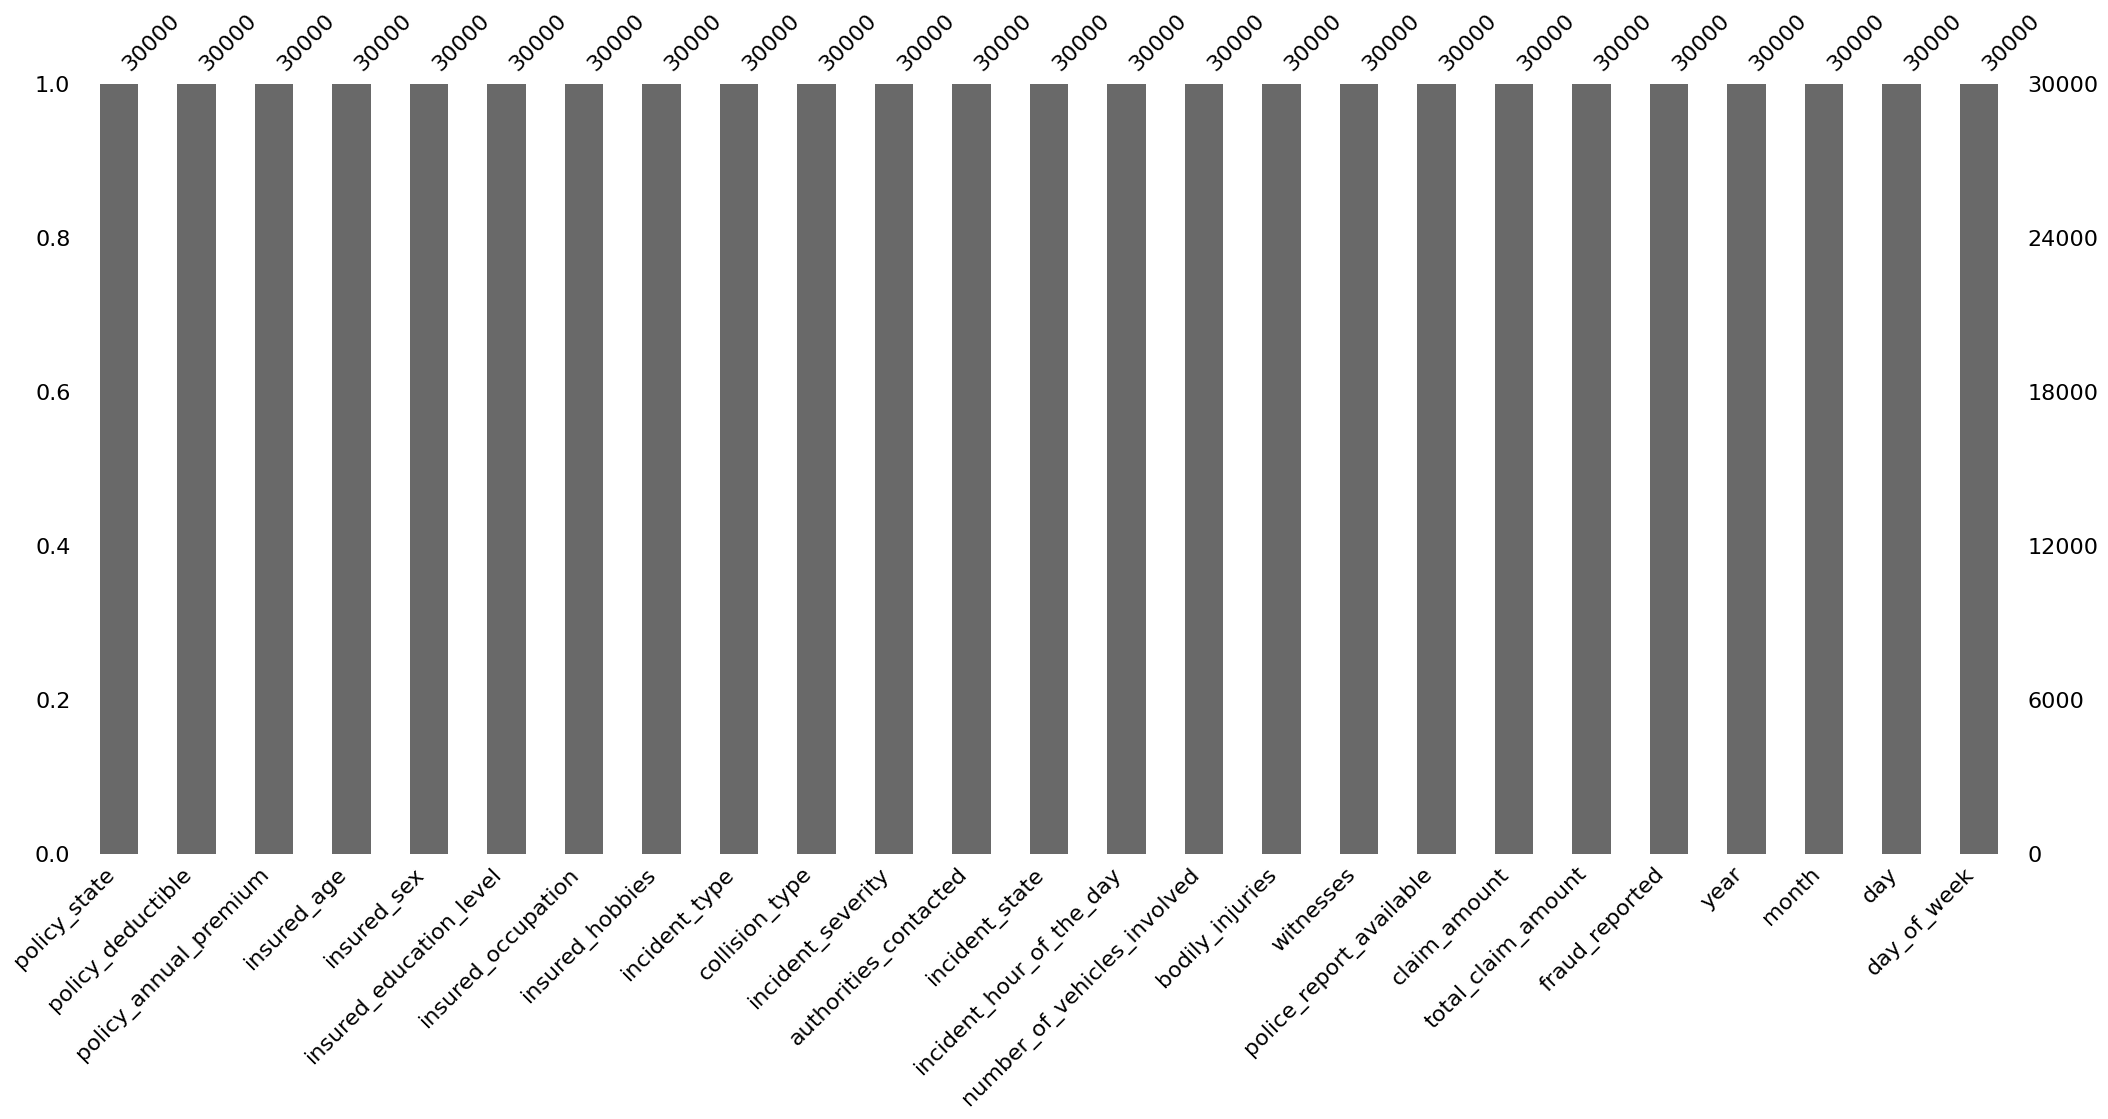

In [211]:
msno.bar(df)

In [212]:
df['incident_severity'].value_counts()

,count
incident_severity,
total loss,10108
major damage,10003
minor damage,9889


In [213]:
df['insured_education_level'].value_counts()

,count
insured_education_level,
high school,7554
phd,7514
masters,7477
college,7455


In [214]:
df.columns

Index(['policy_state', 'policy_deductible', 'policy_annual_premium',
       'insured_age', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
       'police_report_available', 'claim_amount', 'total_claim_amount',
       'fraud_reported', 'year', 'month', 'day', 'day_of_week'],
      dtype='object')

Visulization

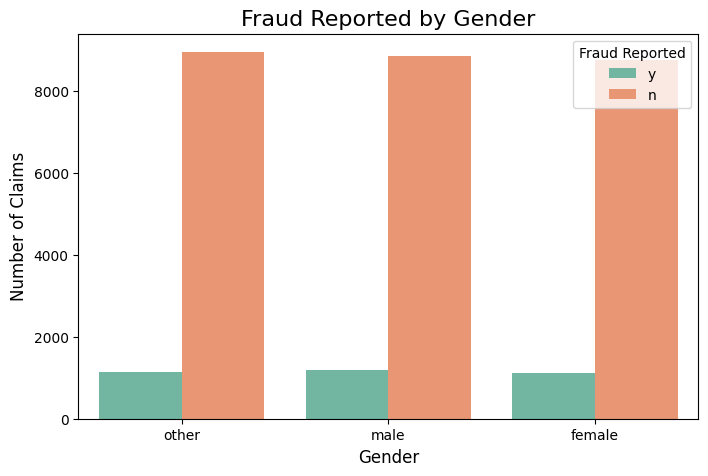

In [215]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='insured_sex',
    hue='fraud_reported',
    palette='Set2'
)

plt.title("Fraud Reported by Gender", fontsize=16)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Claims", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Fraud Reported', fontsize=10)
plt.show()

In [216]:
df.columns

Index(['policy_state', 'policy_deductible', 'policy_annual_premium',
       'insured_age', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
       'police_report_available', 'claim_amount', 'total_claim_amount',
       'fraud_reported', 'year', 'month', 'day', 'day_of_week'],
      dtype='object')

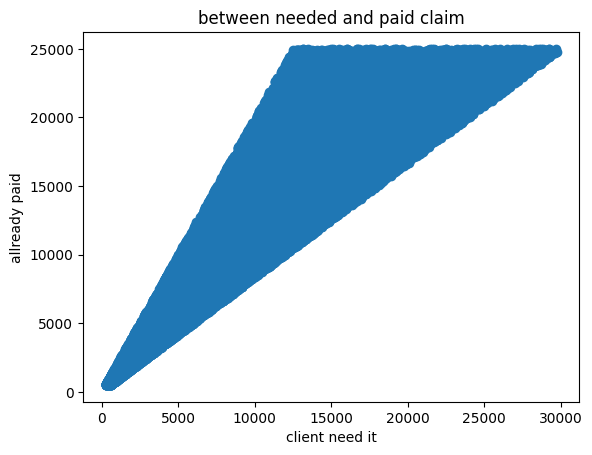

In [217]:
plt.scatter(df['claim_amount'], df['total_claim_amount'])
plt.xlabel('client need it')
plt.ylabel('allready paid')
plt.title('between needed and paid claim')
plt.show()

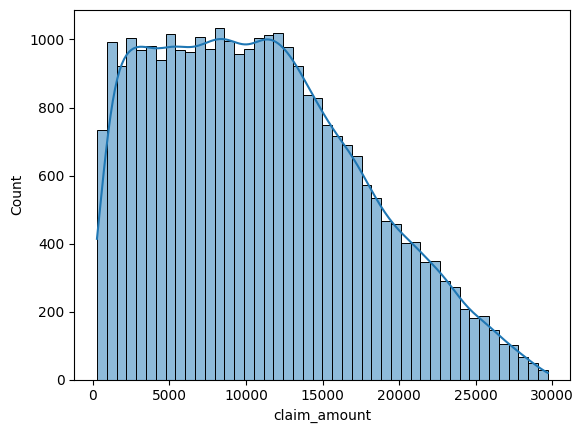

In [135]:
sns.histplot(df['claim_amount'], kde=True)
plt.show()

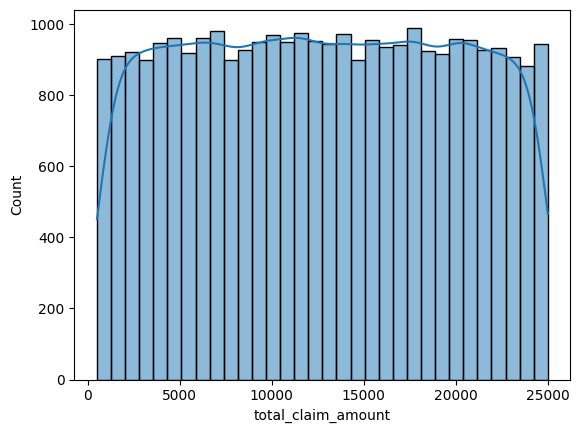

In [136]:
sns.histplot(df['total_claim_amount'], kde=True)
plt.show()

Splitting data

In [137]:
x = df.drop('fraud_reported', axis=1)
y = df['fraud_reported'].map({'n':0, 'y':1})

In [138]:
y.value_counts()

,count
fraud_reported,
0,26560
1,3440


In [139]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Encoding

In [140]:
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)

Alignment to unify columns in x, to prevent data leakage

In [141]:
x_train,x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

Scaling then Balancing

In [142]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [143]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train_scaled, y_train)

Models

Logistic Regression

In [144]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model1 = LogisticRegression(C=0.04,class_weight='balanced',solver='lbfgs',random_state=42)
model1.fit(x_train_res, y_train_res)

LogisticRegression(C=0.04, class_weight='balanced', random_state=42)

In [145]:
y_pred1 = model1.predict(x_test_scaled)
y_pred1

array([1, 1, 1, ..., 1, 0, 0])

In [146]:
print("Training acc: ", model1.score(x_train_res, y_train_res)*100)
print("Testing acc: ", model1.score(x_test_scaled, y_test)*100)

Training acc:  69.05355798192771
Testing acc:  69.13333333333334


In [147]:
print("confusion matrix:",confusion_matrix(y_test, y_pred1))

confusion matrix: [[3726 1586]
 [ 266  422]]


In [148]:
print("classification report:",classification_report(y_test, y_pred1))

classification report:               precision    recall  f1-score   support

           0       0.93      0.70      0.80      5312
           1       0.21      0.61      0.31       688

    accuracy                           0.69      6000
   macro avg       0.57      0.66      0.56      6000
weighted avg       0.85      0.69      0.75      6000



KNN

In [149]:
from sklearn.neighbors import KNeighborsClassifier
model2 = KNeighborsClassifier(n_neighbors=7)
model2.fit(x_train_res, y_train_res)

KNeighborsClassifier(n_neighbors=7)

In [150]:
y_pred2 = model2.predict(x_test_scaled)
y_pred2

array([1, 0, 1, ..., 1, 1, 0])

In [151]:
print("Training acc:", model2.score(x_train_res, y_train_res)*100)
print("Testing acc:", model2.score(x_test_scaled, y_test)*100)

Training acc: 73.3433734939759
Testing acc: 40.06666666666667


In [152]:
print("confusion matrix:",confusion_matrix(y_test, y_pred2))

confusion matrix: [[1938 3374]
 [ 222  466]]


In [153]:
print("classification report:",classification_report(y_test, y_pred2))

classification report:               precision    recall  f1-score   support

           0       0.90      0.36      0.52      5312
           1       0.12      0.68      0.21       688

    accuracy                           0.40      6000
   macro avg       0.51      0.52      0.36      6000
weighted avg       0.81      0.40      0.48      6000



Random Forest

In [154]:
from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier(n_estimators=10,max_depth=None
                                ,min_samples_split=5,min_samples_leaf=3
                                ,class_weight='balanced',random_state=42)
model3.fit(x_train_res, y_train_res)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=3,
                       min_samples_split=5, n_estimators=10, random_state=42)

In [155]:
y_pred3 = model3.predict(x_test_scaled)
y_pred3

array([0, 0, 0, ..., 0, 0, 0])

In [156]:
print("Training acc:", model3.score(x_train_res, y_train_res)*100)
print("Testing acc:", model3.score(x_test_scaled, y_test)*100)

Training acc: 96.90794427710844
Testing acc: 87.83333333333333


In [157]:
print("confusion matrix:",confusion_matrix(y_test, y_pred3))

confusion matrix: [[5235   77]
 [ 653   35]]


In [158]:
print("classification report:",classification_report(y_test, y_pred3))

classification report:               precision    recall  f1-score   support

           0       0.89      0.99      0.93      5312
           1       0.31      0.05      0.09       688

    accuracy                           0.88      6000
   macro avg       0.60      0.52      0.51      6000
weighted avg       0.82      0.88      0.84      6000



XGBoost

In [159]:
from joblib.externals.loky.process_executor import MAX_DEPTH
from xgboost import XGBClassifier
model4 = XGBClassifier(random_state=42,use_label_encoder=False
                      , n_estimators=55,MAX_DEPTH=20
                       ,learning_rate=0.03,subsample=0.8
                       ,eval_metric='logloss')
model4.fit(x_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:42:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "MAX_DEPTH", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(MAX_DEPTH=20, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=55, n_jobs=None, ...)

In [160]:
y_pred4 = model4.predict(x_test_scaled)
y_pred4

array([0, 0, 1, ..., 0, 0, 0])

In [161]:
print("Training acc:", model4.score(x_train_res, y_train_res)*100)
print("Testing acc:", model4.score(x_test_scaled, y_test)*100) #4.6

Training acc: 92.21103162650603
Testing acc: 87.6


In [162]:
print("confusion matrix:",confusion_matrix(y_test, y_pred4))

confusion matrix: [[5147  165]
 [ 579  109]]


<Axes: >

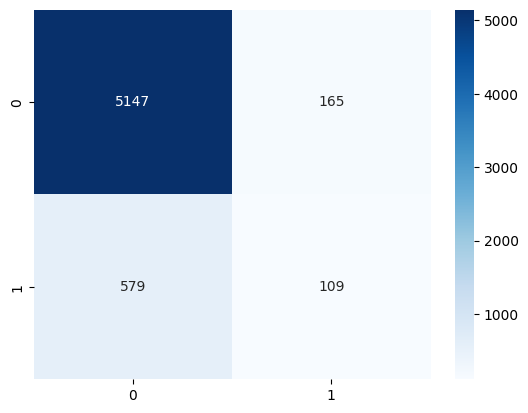

In [163]:
sns.heatmap(confusion_matrix(y_test, y_pred4), annot=True, fmt='d', cmap='Blues')

In [164]:
print("classification report:",classification_report(y_test, y_pred4))

classification report:               precision    recall  f1-score   support

           0       0.90      0.97      0.93      5312
           1       0.40      0.16      0.23       688

    accuracy                           0.88      6000
   macro avg       0.65      0.56      0.58      6000
weighted avg       0.84      0.88      0.85      6000



Downloading

In [165]:
import pickle
with open('xgb_model.pkl', 'wb') as file:
    pickle.dump(model4, file)

In [166]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

In [167]:
with open('colums.pkl', 'wb') as file:
    pickle.dump(x_train.columns, file)

In [168]:
!ls

colums.pkl  drive  sample_data	scaler.pkl  xgb_model.pkl
